Põhiline inspiratsioon Metropolis Hastingu kohta: https://blog.djnavarro.net/posts/2023-04-12_metropolis-hastings/#the-problem

## Tihedusfunktsioon

Uurimise all on tihedusfunktsioon (normeerimata tihedusfunktsioon) $$p(x) \propto \exp(-x^2)(2+\sin(5x)+\sin(2x))$$


## Markov Chain Monte Carlo 1D sisendiga tiheduste jaoks 
### Metropolis-Hastings Random Walk algoritm (proposal tõenäosus pole tinglik või on sümmeetriline)


**Ühe sammu arvutuseeskiri**
$$\begin{align*}
&x' = x_n + \Delta, \quad \Delta \sim \mathcal{N}(0, \sigma),\\
&\mathbb{P}\{\text{"acceptance"}\} = \min (1, \frac{p(x')}{p(x_n)}),\\
&\alpha \sim \text{Uniform}(0,1),\\
&x_{n+1} = \begin{cases}
x'\quad \text{kui } \mathbb{P}\{\text{"acceptance"}\} \geq \alpha, \\ 
x_n \quad \text{muidu}.
\end{cases}
\end{align*}$$


### Hamiltoni Monte Carlo

Parameetrid $K, L, M, \Delta t$ on vastavalt samplite $q_{n}$ arv, integreerimissammude arv, mass (üldisel juhul massimaatriks), ajasamm (kirjanduses tähistatakse kui $\epsilon$).
Arvutustes initsialiseerin massi väärtuseks 1. Juhusliku suuruse dispersioon pidavat olema optimaalne massi väärtus, mida saab ahela "soojendusfaasis" määrata...(tegelen hiljem)

Iga järgmise sample'i $q_{n+1}$ arvutamiseks teostatakse algtingimusega ülesanne. Lõpus otsustatakse teatava Hamiltoni heuristika järgi koostatud, _acceptance probability_ järgi, kas uus sample võetakse ahelasse.

$$\begin{align*}
&p_{0} \sim \mathcal{N}(0, M),\\
&q_{i = 0} = q_n,\\

&\text{for } i = 0,...,L-1 \text{ do}\\
&\quad \quad p_{i+\frac{1}{2}} = p_{i} + \frac{\Delta t}{2} \nabla U(q_{i}),\\
&\quad \quad q_{i+1} = q_{i} + M^{-1} p_{i+\frac{1}{2}},\\
&\quad \quad p_{i+1} = p_{i+\frac{1}{2}} + \frac{\Delta t}{2} \nabla U(q_{i+1}),\\

&\mathbb{P}\{\text{"acceptance"}\} = \min\left(-H(q_L, -p_L)+H(q_0, p_0))\right),\\
&\alpha \sim \text{Uniform}(0,1).\\
&q_{n+1} = \begin{cases} 
q_{L}, \quad \text{kui } \mathbb{P}\{\text{"acceptance"}\} \geq \alpha,\\
q_{n}, \quad \text{muidu}.
\end{cases}

\end{align*}$$


Rakendan diferentsmeetodeid, et leida potentsiaaligradiendid $\nabla U(q)$.

Sümmeetriline diferentsskeem 1D potentsiaaligradiendi leidmiseks

$$\frac{d U(q)}{dq} \approx \frac{U(q+h) - U(q-h)}{2h}. $$

Alternatiivselt saab gradiendi määramiseks rakendada _automatic differentiation_ maagiat.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad #numbriliseks integreerimiseks
from scipy.stats import norm 

### Tihedusfunktsioon koodis

In [2]:
def pdf_lugeja(x):
    return np.exp(-x**2)*(2+np.sin(5*x)+np.sin(2*x))

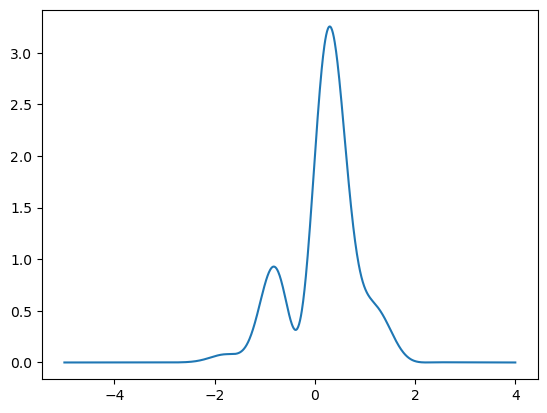

In [3]:
t = np.linspace(-5, 4, 1000)
pdf_values = pdf_lugeja(t)
plt.plot(t, pdf_values)
plt.show()

### Tihedusfunktsiooni normeerimine

In [4]:
#numbrilise integreerimise kaudu üle "kogu" määramispiirkonna ehk intervallil [-lõpmatus, lõpmatus], kus lõpmatus = 10  
norm = quad(pdf_lugeja, -10, 10)
norm = norm[0]
norm

3.544907701811032

In [5]:
#normeeritud variant sellest tihedusfunktsioonist
pdf_norm = lambda x : pdf_lugeja(x)/norm

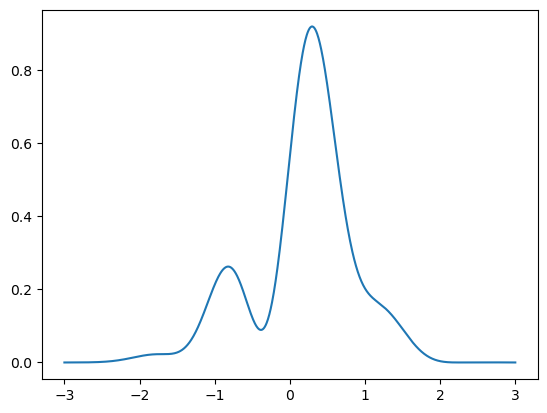

In [6]:
t = np.linspace(-3, 3, 1000)
pdf_values = pdf_norm(t)
plt.plot(t, pdf_values)
plt.show()

In [7]:
norm2 = quad(pdf_norm, -10, 10)
norm2 # on tõepoolest enam-vähem normeeritud nüüd

(0.9999999999999999, 6.867540396714953e-10)

### Keskväärtuse ja standardhälve hindamine

$$\begin{align*}
&E(x) = \int xf(x) dx\\
&E(x^2) = \int x^2f(x) dx\\
&\sigma^2 = E(x^2) - E(x)^2

\end{align*}$$

In [8]:
keskväärtuseIntegrand = lambda x: x*pdf_norm(x)
teiseMomendiIntegrand = lambda x: x**2 *pdf_norm(x)

In [9]:
keskväärtus = quad(keskväärtuseIntegrand, -100, 100)
keskväärtus

(0.1863527882560058, 3.5126589770847084e-09)

In [10]:
teineMoment = quad(teiseMomendiIntegrand, -100, 100)
teineMoment

(0.49999999999999994, 3.526603395160449e-09)

In [11]:
oodatav_std = np.sqrt(teineMoment[0] - keskväärtus[0]**2)
oodatav_std

0.6821089636628537

## Meetodite kirjutamine koodis

### Just in time kompilaatorite ja automaatse diferentseerimise katsetamine
TODO: just-in-time kompilaatorite toimiv rakendamine kõigile meetoditele

In [12]:
#JIT jaoks
import numba

In [13]:
def test(n):
    k=0
    for i in range(n):
        for j in range(n):
            for k in range(n):
                k+=1


In [15]:
@numba.jit
def testjit(x):
    w=0
    for i in range(x):
        for j in range(x):
            for k in range(x):
                w+=1
    return w

In [17]:
testjit(1000000) == 1000000**3 #-> 10^6 on suurim väljund enne kui float katki läheb, võtab aega 0.4s, puhas maagia

True

In [18]:
#autodiffi jaoks on kavas kasutada jax-i
import jax
import jax.numpy as jnp

In [19]:
@jax.jit
def pdf_JIT(x):
    return jnp.exp(-x**2)*(2+jnp.sin(5*x)+jnp.sin(2*x))

In [20]:
@jax.jit
def U_JIT(x):
    return -jnp.log(jnp.exp(-x**2)*(2+jnp.sin(5*x)+jnp.sin(2*x)))

### Autodiff katsetamine

In [21]:
grad_U_JIT = jax.grad(U_JIT)

print(grad_U_JIT(1.0))  # arvutas tuletise autodiffi kasutades - WOW

1.6995356


## Metropolis Hastings algoritm koodis

In [22]:
@numba.jit
def pdf_JIT_norm(x):
    return np.exp(-x**2)*(2+np.sin(5*x)+np.sin(2*x))/norm
@numba.jit
def RandomWalkMetropolisHastings(x0, sigma, n):
        x = np.zeros(n)
        x[0] = x0
        for k in range(1,n):
            x_next = x[k-1] + np.random.normal(0, sigma)
            acceptance_probability = min(1, pdf_JIT_norm(x_next)/pdf_JIT_norm(x[k-1]))
            alpha = np.random.uniform(0, 1)
            if alpha < acceptance_probability:
                x[k] = x_next
            else:
                x[k] = x[k-1]
        return x

In [47]:
#parameetrid
x0 = 1.0 #initsialiseerimine alaku pdf-st kaugelt
n = 2000 #olgu kokku 10000 samplit
burnin = 100 #eemaldan algusest 100 samplit
M = 1.0 #mass
L = 100 #algtingimusega ülesande sammude arv

In [48]:
lahendMH = RandomWalkMetropolisHastings(x0, 1.0, n)
lahendMH_burnin = lahendMH[burnin:]

## Hamiltoni Monte Carlo koodis

In [49]:
@numba.jit
def K(self, p, M):
    return 0.5 * p**2 / M

@numba.jit
def U(x):
    return -np.log(pdf_JIT_norm(x))

#hamiltoniaan
@numba.jit
def Ha(x, p, M):
    # Hamiltonian = U + K
    return U(x) + 0.5 * p**2 / M
    
# diferentsmeetodite gradient
@numba.jit
def gradU(x, h):
    return (U(x + h) - U(x - h)) / (2*h)
@numba.jit    
def HamiltonianMonteCarloMarkovChain(L, K, x0, epsilon, M):

    x = np.zeros(K)
    x[0] = x0

    for k in range(1, K):
        #uus impulss
        p_next = np.random.normal(0, np.sqrt(M))
        p0 = p_next
        x_next = x[k-1]

        # --- leapfrog integreerimine ---
        for i in range(L):
            p_next = p_next - 0.5 * epsilon * gradU(x_next, h=0.001)
            x_next = x_next + epsilon * p_next / M
            p_next = p_next - 0.5 * epsilon * gradU(x_next, h=0.001)

        #acceptance tõenäosus
        acceptance_probability = min(1, 
            np.exp(
                Ha(x[k-1], p0, M) - 
                Ha(x_next, -p_next, M)
            ))

        alpha = np.random.uniform(0, 1)

        #accept või reject
        if alpha < acceptance_probability:
            x[k] = x_next
        else:
            x[k] = x[k-1]

    return x

In [50]:
lahendHMC = HamiltonianMonteCarloMarkovChain(L, n, x0, 0.01, M)
lahendHMC_burnin = lahendHMC[burnin:]

## Leitud samplite trajektoorid ja histogramm selle kohal

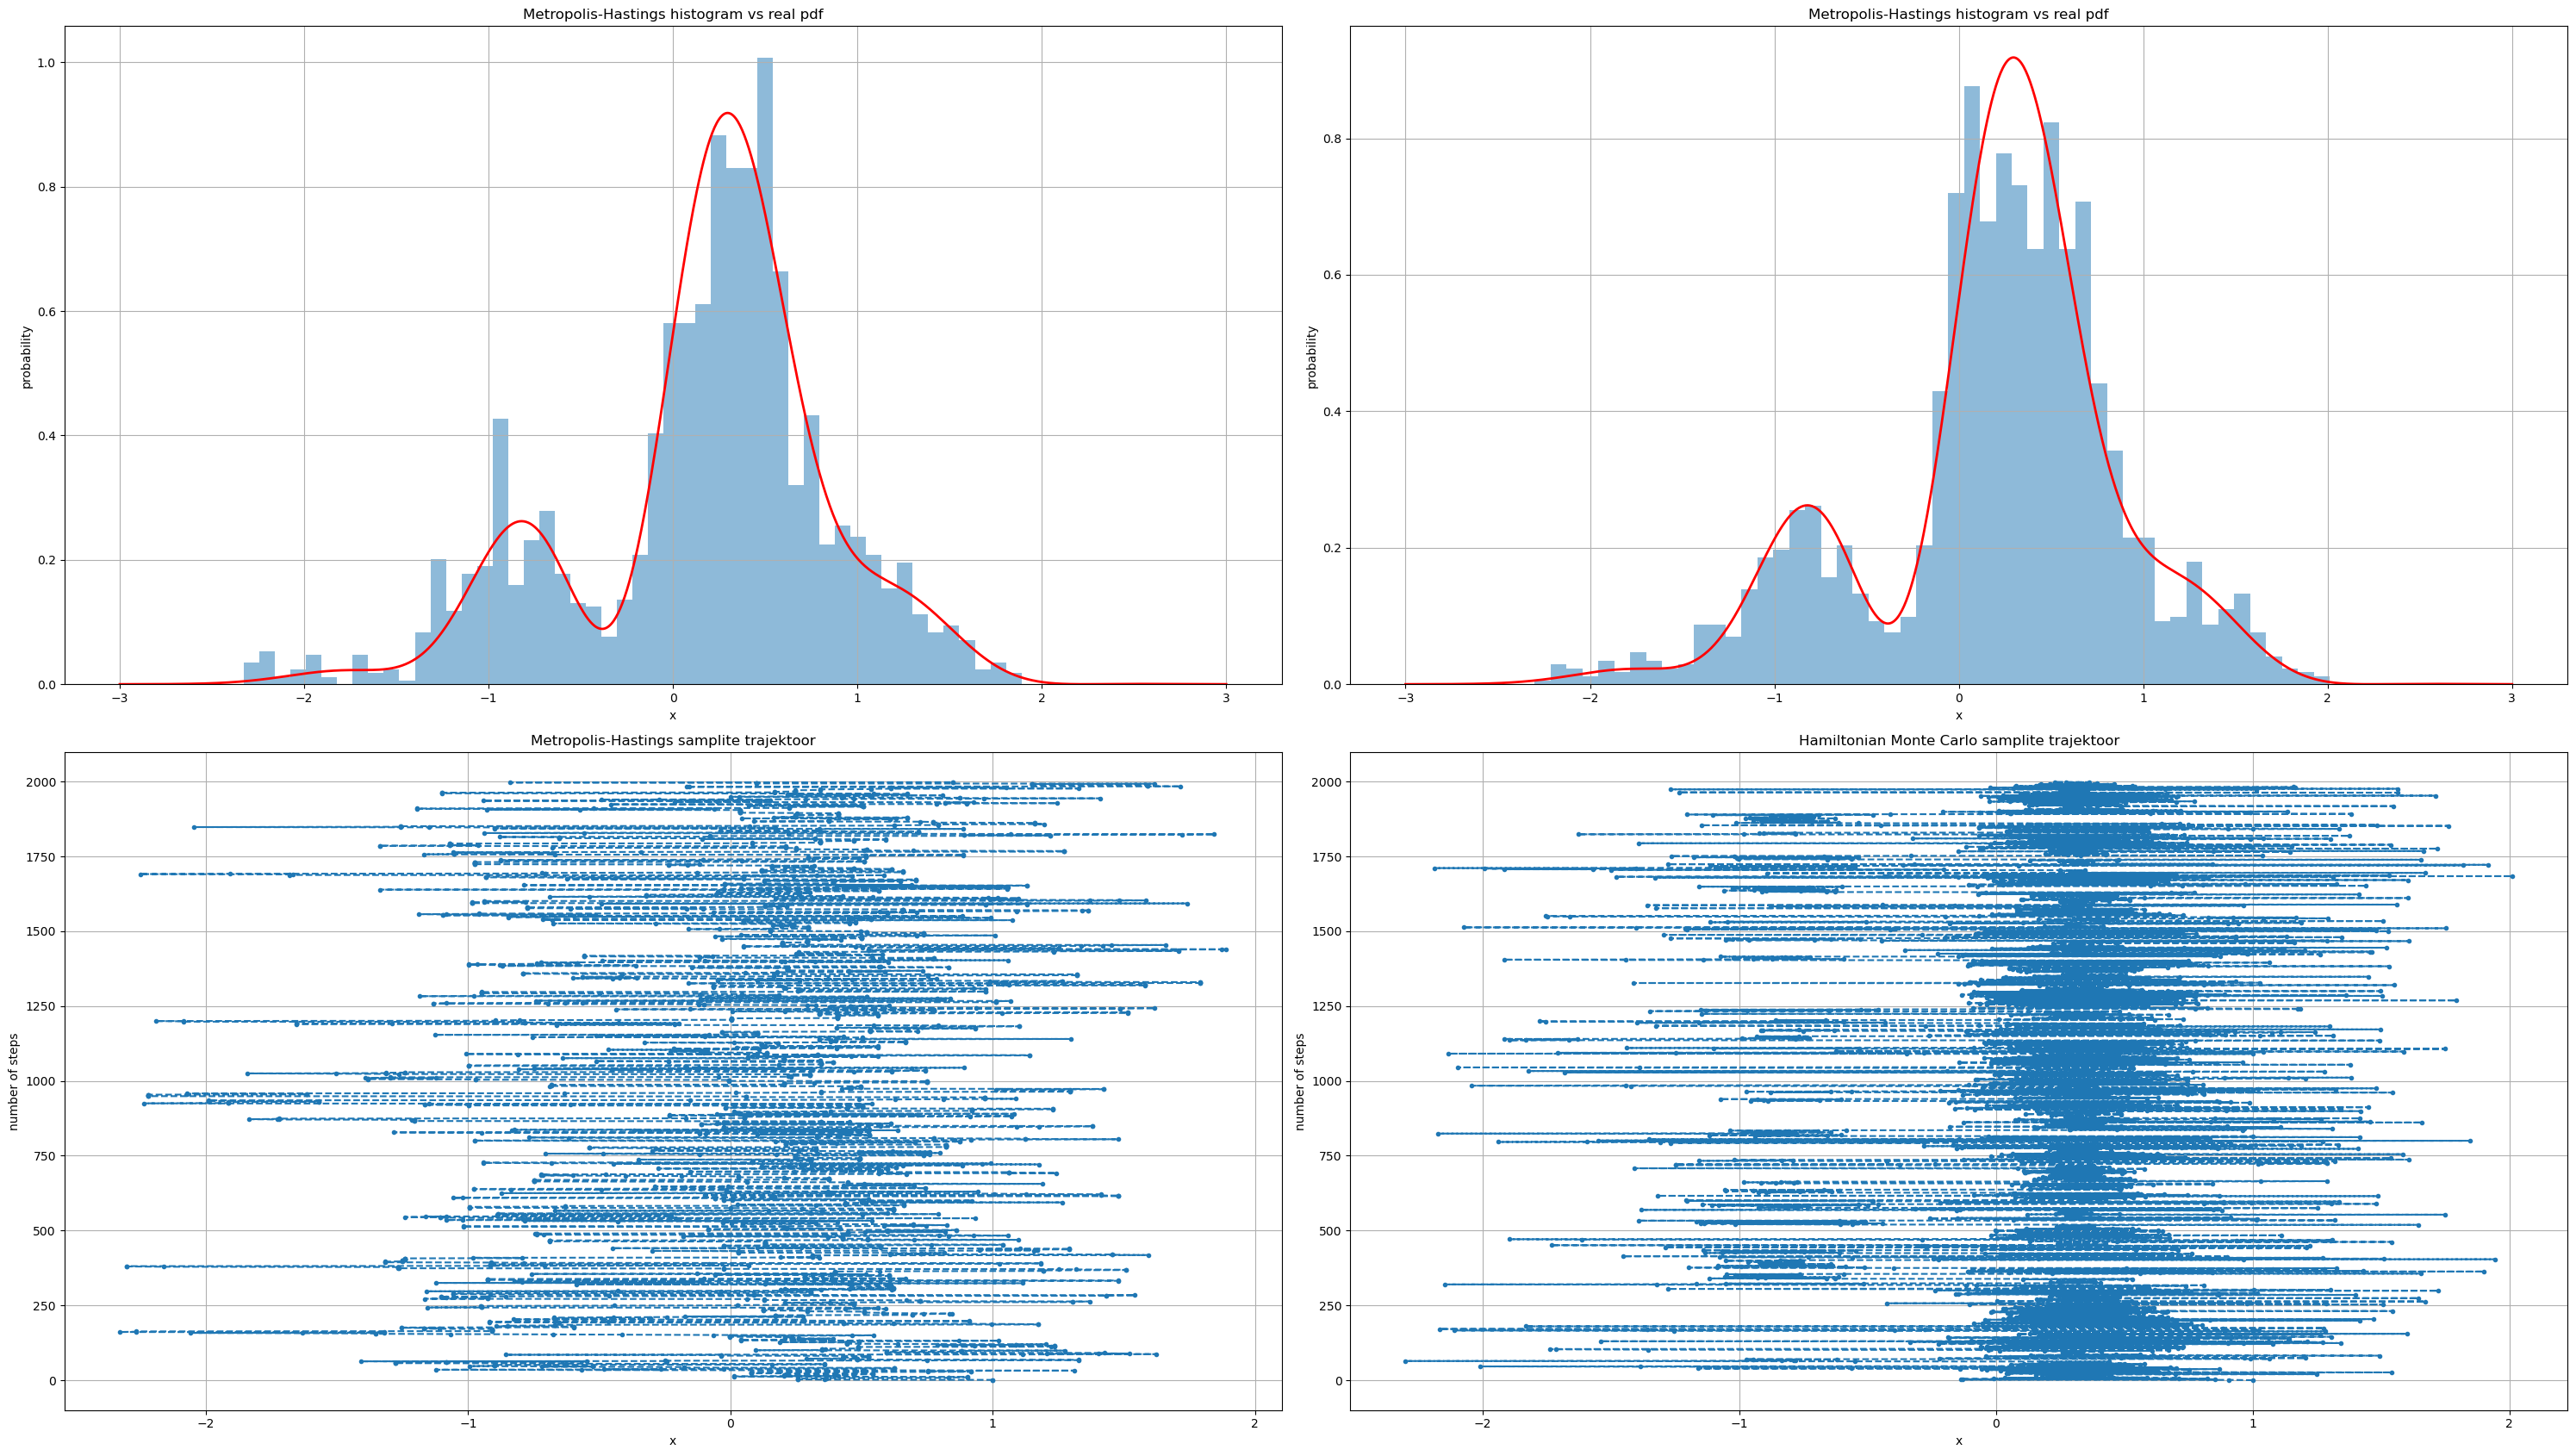

In [54]:
fig, ax = plt.subplots(2, 2, figsize=(30, 17))
ax[1,0].plot(lahendMH[:len(lahendMH)], np.arange(len(lahendMH)), marker='o', linestyle='--', markersize=3)
ax[1,0].set_title('Metropolis-Hastings samplite trajektoor')
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('number of steps')
ax[1,0].grid()
ax[0,0].hist(lahendMH, bins=50, density=True, alpha=0.5)
ax[0,0].plot(t, pdf_values, 'r-', lw=2)
ax[0,0].set_title(f'Metropolis-Hastings histogram vs real pdf')
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('probability')
#ax[0,0].legend()
ax[0,0].grid()

ax[1,1].plot(lahendHMC[:len(lahendHMC)], np.arange(len(lahendHMC)), marker='o', linestyle='--', markersize=3)
ax[1,1].set_title('Hamiltonian Monte Carlo samplite trajektoor')
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('number of steps')
ax[1,1].grid()
ax[0,1].hist(lahendHMC, bins=50, density=True, alpha=0.5)
ax[0,1].plot(t, pdf_values, 'r-', lw=2)
ax[0,1].set_title(f'Metropolis-Hastings histogram vs real pdf')
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('probability')
#ax[0,1].legend()
ax[0,1].grid()


plt.tight_layout()
plt.show()


In [33]:
algusekslemineMH = lahendMH[:burnin]
algusekslemineHMC = lahendHMC[:burnin]

## Ekslemine alguses

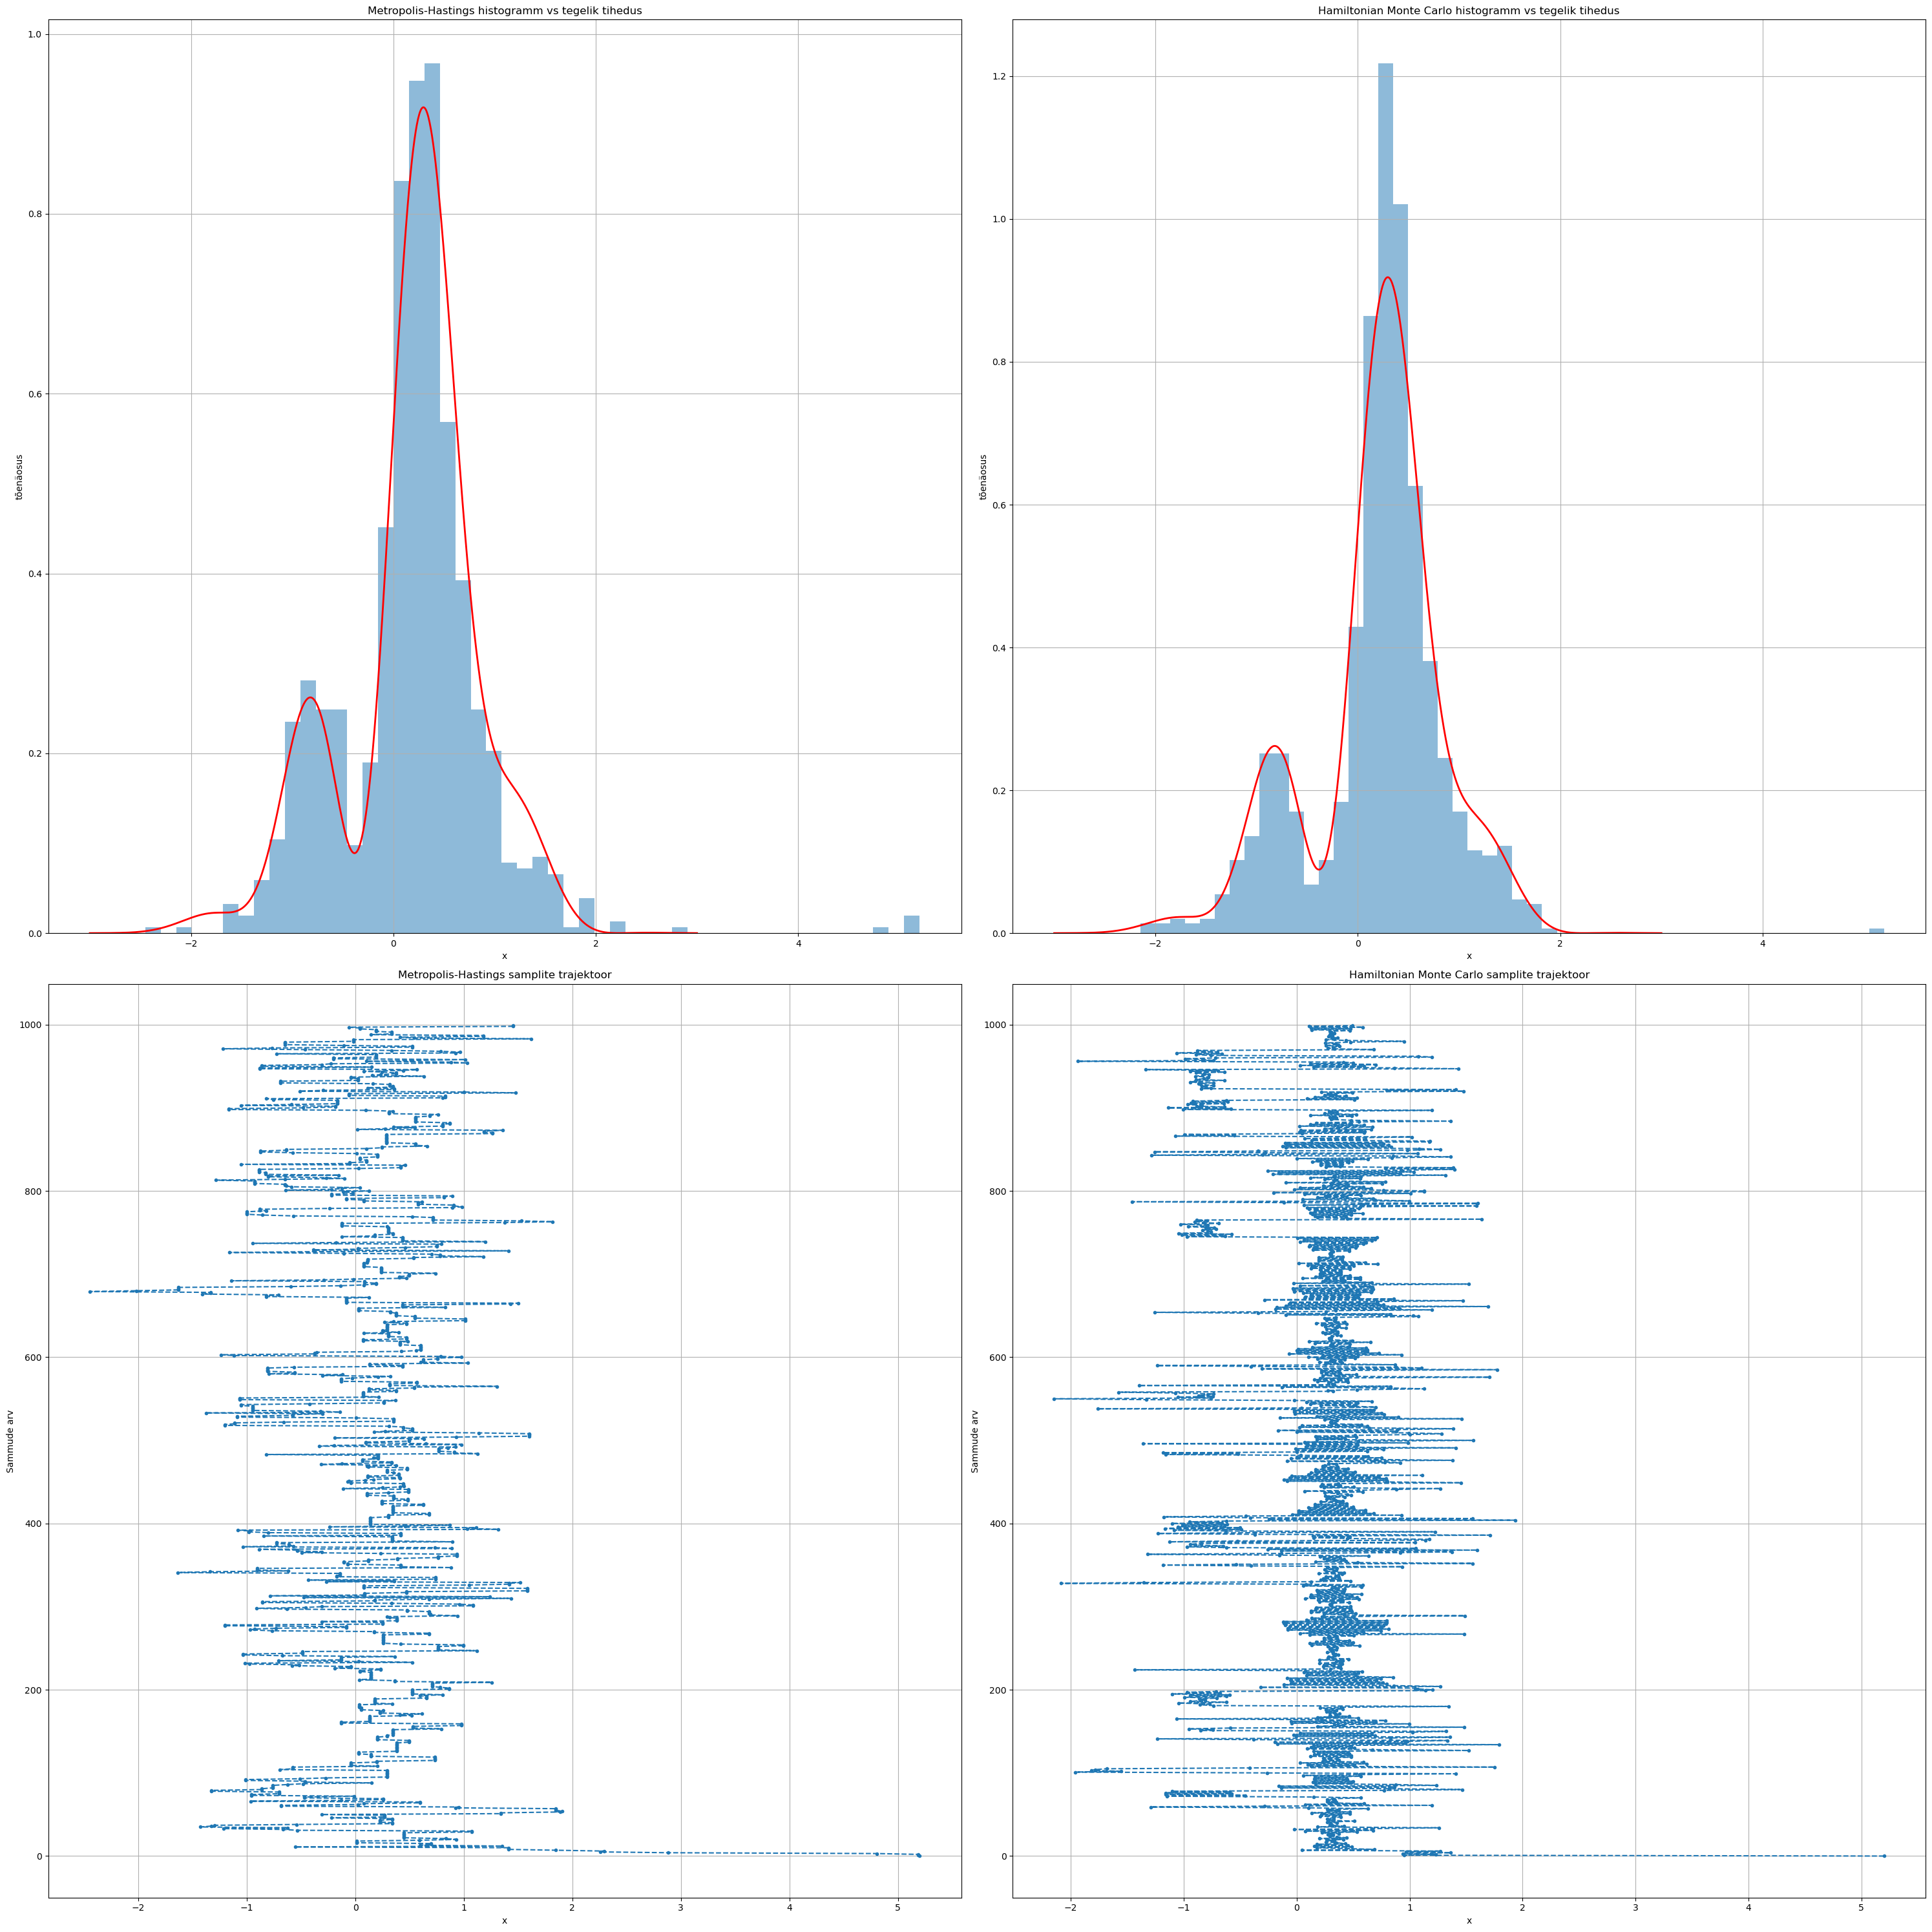

In [34]:
fig, ax = plt.subplots(2, 2, figsize=(30, 30))
ax[1,0].plot(algusekslemineMH[:len(algusekslemineMH)], np.arange(len(algusekslemineMH)), marker='o', linestyle='--', markersize=3)
ax[1,0].set_title('Metropolis-Hastings samplite trajektoor')
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('Sammude arv')
ax[1,0].grid()
ax[0,0].hist(algusekslemineMH, bins=50, density=True, alpha=0.5)
ax[0,0].plot(t, pdf_values, 'r-', lw=2)
ax[0,0].set_title(f'Metropolis-Hastings histogramm vs tegelik tihedus')
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('tõenäosus')
#ax[0,0].legend()
ax[0,0].grid()

ax[1,1].plot(algusekslemineHMC[:len(algusekslemineHMC)], np.arange(len(algusekslemineHMC)), marker='o', linestyle='--', markersize=3)
ax[1,1].set_title('Hamiltonian Monte Carlo samplite trajektoor')
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('Sammude arv')
ax[1,1].grid()
ax[0,1].hist(algusekslemineHMC, bins=50, density=True, alpha=0.5)
ax[0,1].plot(t, pdf_values, 'r-', lw=2)
ax[0,1].set_title(f'Hamiltonian Monte Carlo histogramm vs tegelik tihedus')
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('tõenäosus')
#ax[0,1].legend()
ax[0,1].grid()


plt.tight_layout()
plt.show()

## Burn-in samplite eemaldamine

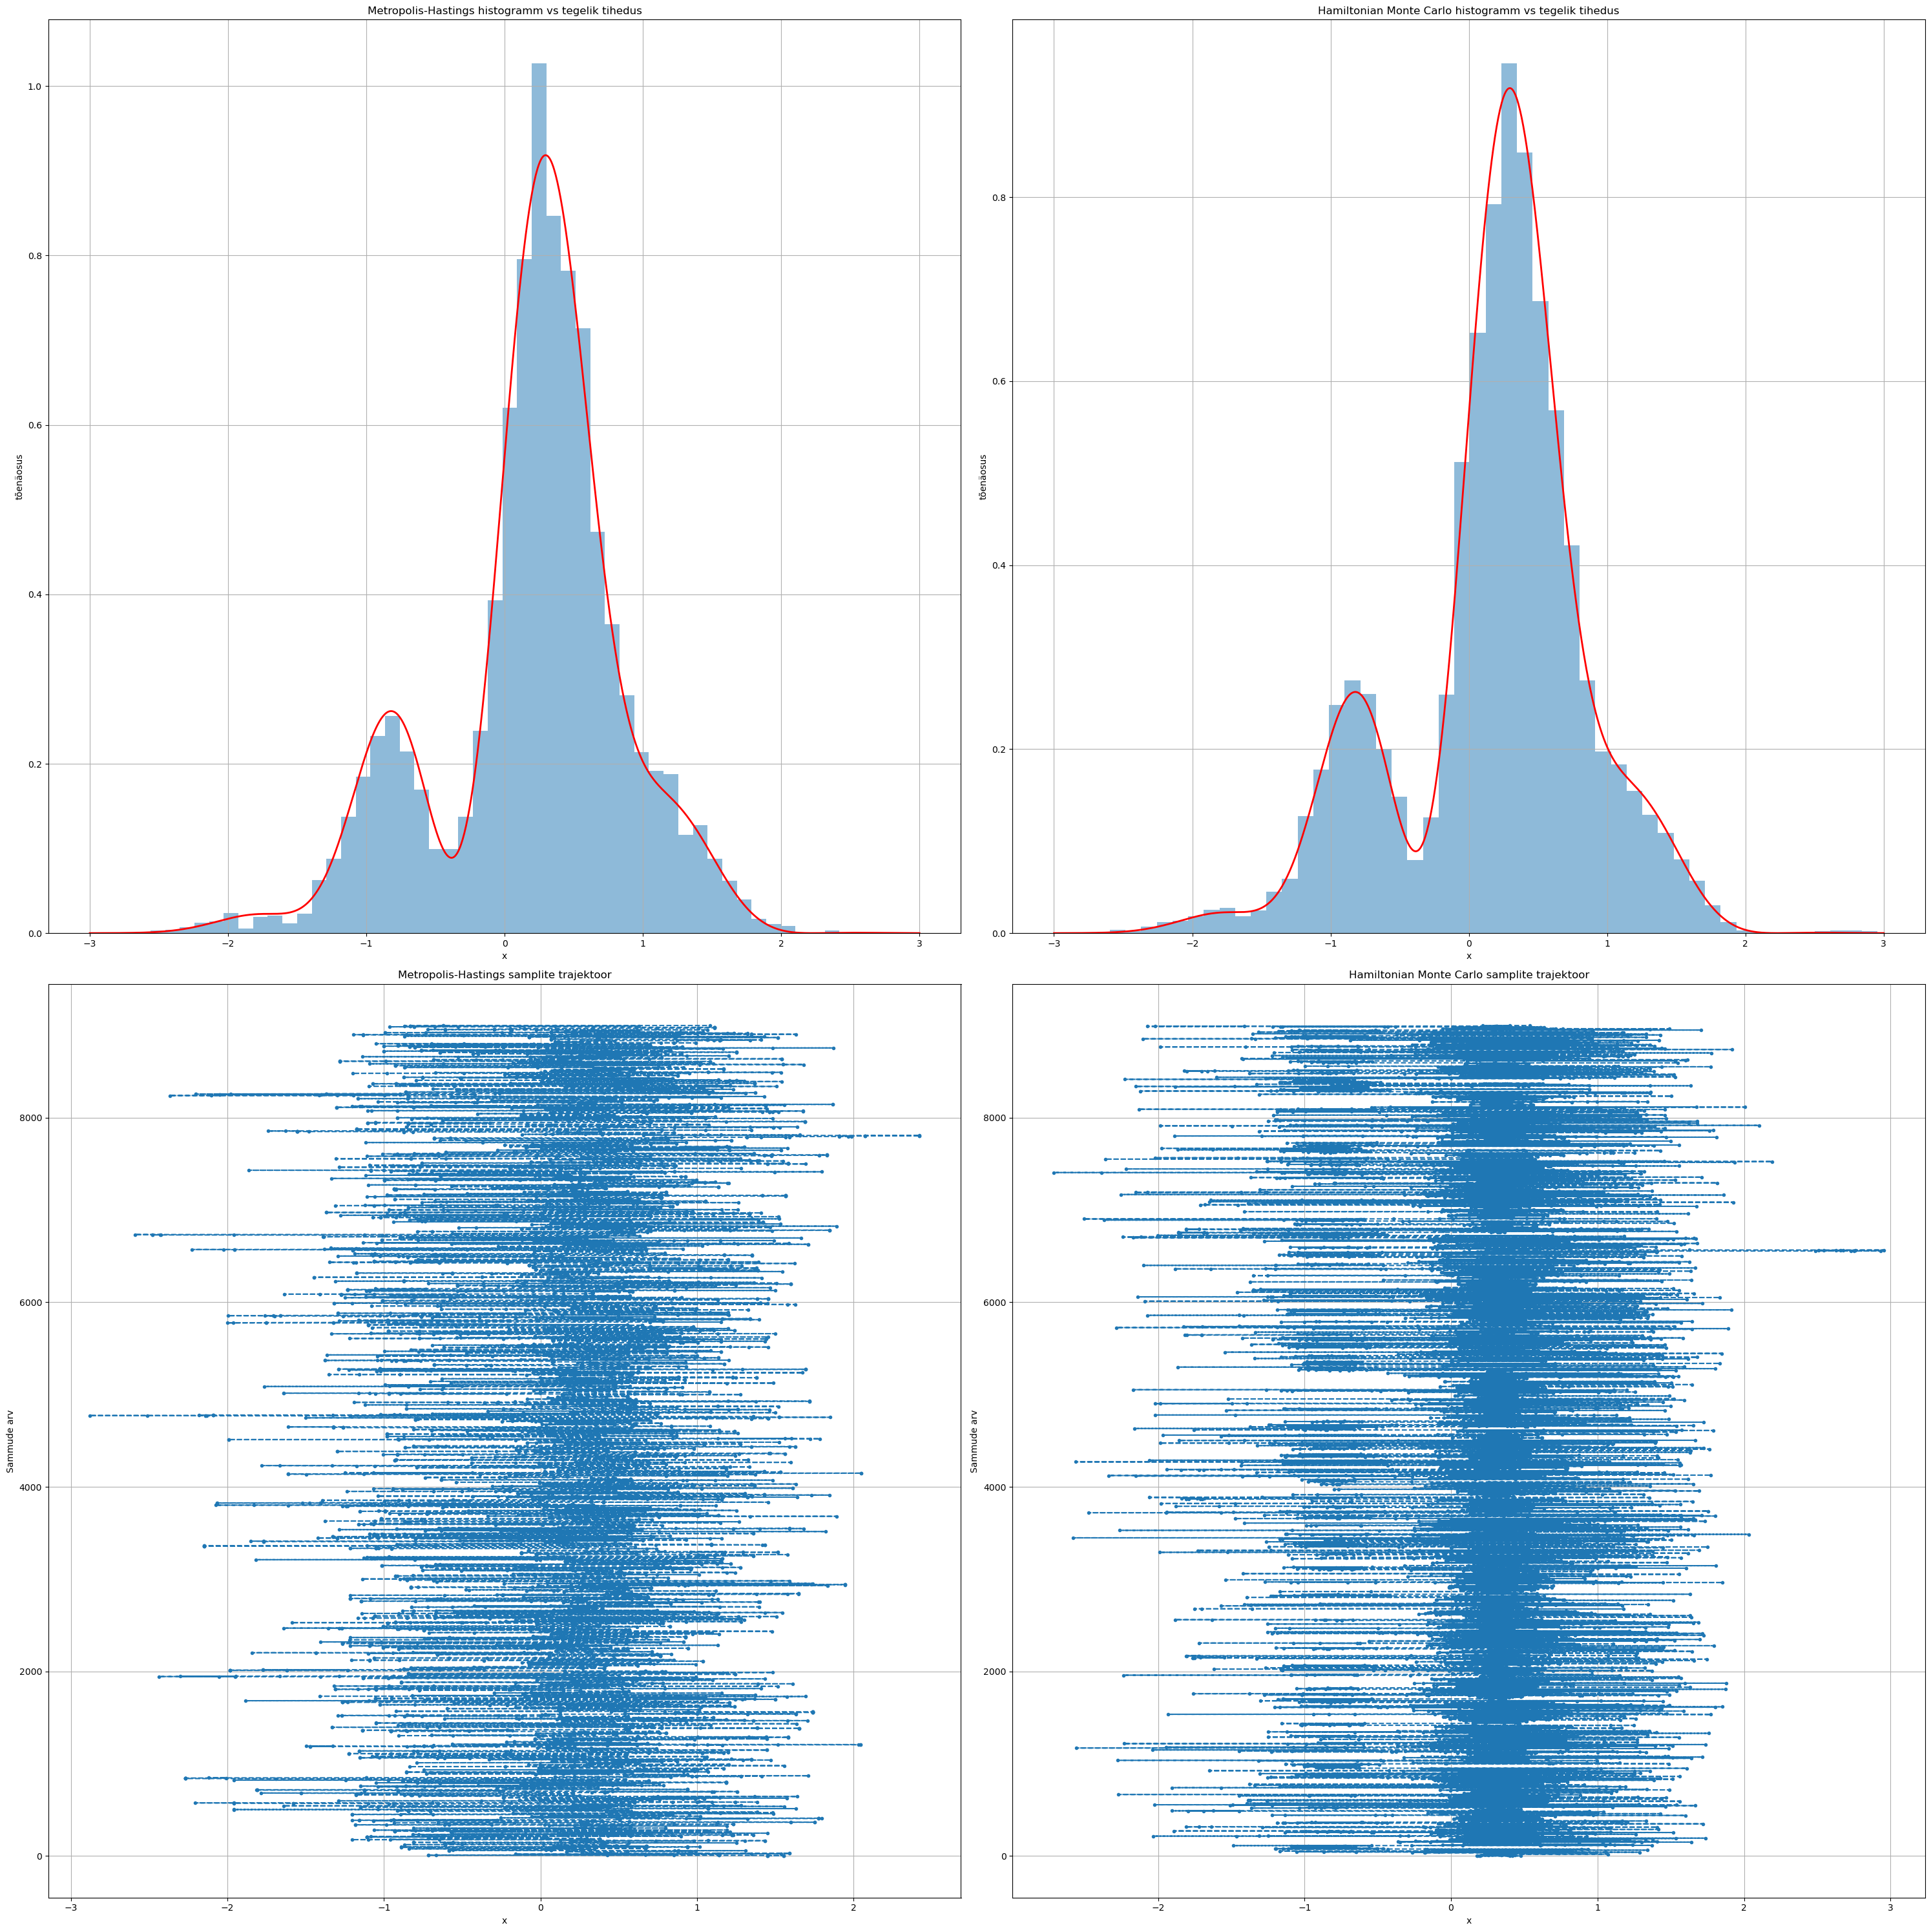

In [35]:
fig, ax = plt.subplots(2, 2, figsize=(30, 30))
ax[1,0].plot(lahendMH_burnin[:len(lahendMH_burnin)], np.arange(len(lahendMH_burnin)), marker='o', linestyle='--', markersize=3)
ax[1,0].set_title('Metropolis-Hastings samplite trajektoor')
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('Sammude arv')
ax[1,0].grid()
ax[0,0].hist(lahendMH_burnin, bins=50, density=True, alpha=0.5)
ax[0,0].plot(t, pdf_values, 'r-', lw=2)
ax[0,0].set_title(f'Metropolis-Hastings histogramm vs tegelik tihedus')
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('tõenäosus')
#ax[0,0].legend()
ax[0,0].grid()

ax[1,1].plot(lahendHMC_burnin[:len(lahendHMC_burnin)], np.arange(len(lahendHMC_burnin)), marker='o', linestyle='--', markersize=3)
ax[1,1].set_title('Hamiltonian Monte Carlo samplite trajektoor')
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('Sammude arv')
ax[1,1].grid()
ax[0,1].hist(lahendHMC_burnin, bins=50, density=True, alpha=0.5)
ax[0,1].plot(t, pdf_values, 'r-', lw=2)
ax[0,1].set_title(f'Hamiltonian Monte Carlo histogramm vs tegelik tihedus')
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('tõenäosus')
#ax[0,1].legend()
ax[0,1].grid()


plt.tight_layout()
plt.show()

## Võrdlus

In [45]:
lahendHMC_burnin = lahendHMC[100:]
lahendMH_burnin = lahendMH[100:]

In [55]:
# keskväärtus ja standardhälve
print(f"\nHMC - Keskväärtus: {np.mean(lahendHMC_burnin):.4f}, standardhälve: {np.std(lahendHMC_burnin):.4f}")
print(f"MH  - Keskväärtus: {np.mean(lahendMH_burnin):.4f}, standardhälve: {np.std(lahendMH_burnin):.4f}")

print(f"Numbrilise integreerimise std ja keskväärtus olid vastavalt: {(oodatav_std):.4f}, {keskväärtus[0]:.4f}")


HMC - Keskväärtus: 0.1817, standardhälve: 0.7053
MH  - Keskväärtus: 0.1351, standardhälve: 0.7323
Numbrilise integreerimise std ja keskväärtus olid vastavalt: 0.6821, 0.1864


### TODO: kõrgema dimensiooniline pdf, mõni keerulisema tüüphulgaga pdf kus HMC-l on eelis

In [56]:
b = 0.9
sigma = 1.4

def pdf_nD(x, y):
    #x, y = x_vec
    return np.exp(-x**2/(2*sigma**2) - (y+b*(x**2-sigma**2))**2/(2*sigma**2))

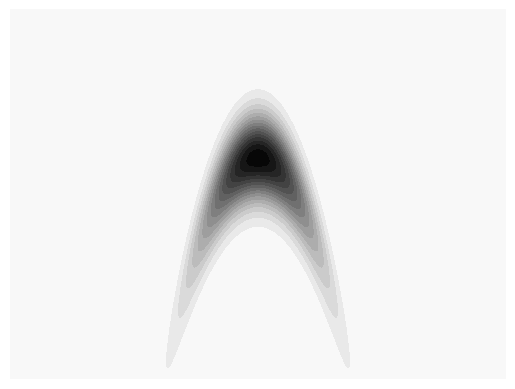

In [88]:
x_grid = np.linspace(-9, 9, 1000)

ux, uy = np.meshgrid(x_grid, x_grid)

plt.contourf(pdf_nD(ux, uy), levels = 16, cmap = "gray_r")
plt.axis("off")
plt.show()

In [58]:
@numba.njit
def pdf_2D_JIT(x, y):
    #x, y = x_vec
    return np.exp(-x**2/(2*sigma**2) - (y+b*(x**2-sigma**2))**2/(2*sigma**2))
@numba.njit
def RandomWalkMetropolisHastings_nD(x0, sigma, n):
        dim = len(x0)
        x_samples = np.zeros((n, dim))
        x_samples[0] = x0
        for k in range(1,n):
            x_next = x_samples[k-1] + np.random.normal(0, sigma, size=dim)
            acceptance_probability = min(1.0, pdf_2D_JIT(x_next[0], x_next[1])/pdf_2D_JIT(x_samples[k-1][0], x_samples[k-1][1]))
            alpha = np.random.uniform(0, 1)
            if alpha < acceptance_probability:
                x_samples[k] = x_next
            else:
                x_samples[k] = x_samples[k-1]
        return x_samples

In [59]:
x0 = np.array([1.0,1.0])

lahendMHMC2D=RandomWalkMetropolisHastings_nD(x0, 1, 10000)

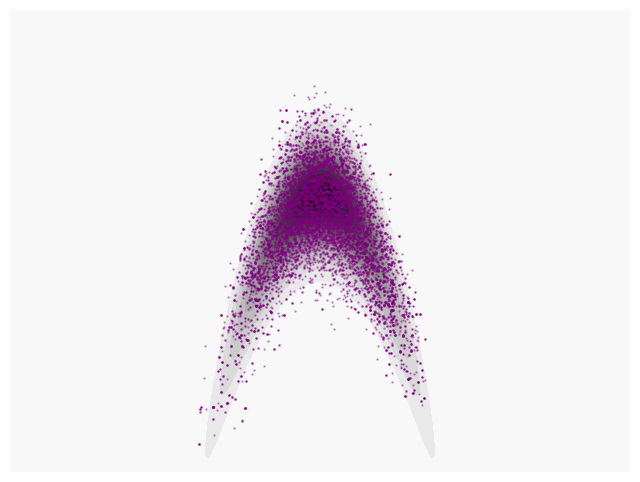

In [72]:

plt.figure(figsize=(8,6))

plt.contourf(x_grid, x_grid, pdf_nD(ux, uy), levels = 16, cmap = "binary")
plt.axis("off")
plt.scatter(lahendMHMC2D.T[0], lahendMHMC2D.T[1], s = 0.5, color = "purple", alpha= 0.4 )
plt.show()

In [61]:
@numba.njit
def U_nD(x):
    return -np.log(pdf_2D_JIT(x[0], x[1]))

@numba.njit
def K_nD(p, M):
    return 0.5 * np.sum(p**2) / M

@numba.njit
def Ha_nD(x, p, M):
    return U_nD(x) + K_nD(p, M)

@numba.njit
def gradU_nD(x, h):
    dim = len(x)
    grad = np.zeros(dim)
    for i in range(dim):
        x_forward = x.copy()
        x_backward = x.copy()
        x_forward[i] += h
        x_backward[i] -= h
        grad[i] = (U_nD(x_forward) - U_nD(x_backward)) / (2*h)
    return grad

@numba.njit
def HamiltonianMonteCarloMarkovChain_nD(L, K_samples, x0, epsilon, M):
    dim = len(x0)
    x_samples = np.zeros((K_samples, dim))
    x_samples[0] = x0.copy()

    for k in range(1, K_samples):
        p_next = np.random.normal(0, np.sqrt(M), size=dim)
        p0 = p_next.copy()
        x_next = x_samples[k-1].copy()

        for i in range(L):
            grad = gradU_nD(x_next, h=1e-3)
            p_next -= 0.5 * epsilon * grad
            x_next += epsilon * p_next / M
            grad = gradU_nD(x_next, h=1e-3)
            p_next -= 0.5 * epsilon * grad

        H_current = Ha_nD(x_samples[k-1], p0, M)
        H_proposed = Ha_nD(x_next, -p_next, M)
        acceptance_probability = min(1.0, np.exp(H_current - H_proposed))

        if np.random.uniform() < acceptance_probability:
            x_samples[k] = x_next
        else:
            x_samples[k] = x_samples[k-1]

    return x_samples

In [84]:
lahendHMC2D=HamiltonianMonteCarloMarkovChain_nD(35, 10000, x0, 0.01, 1)

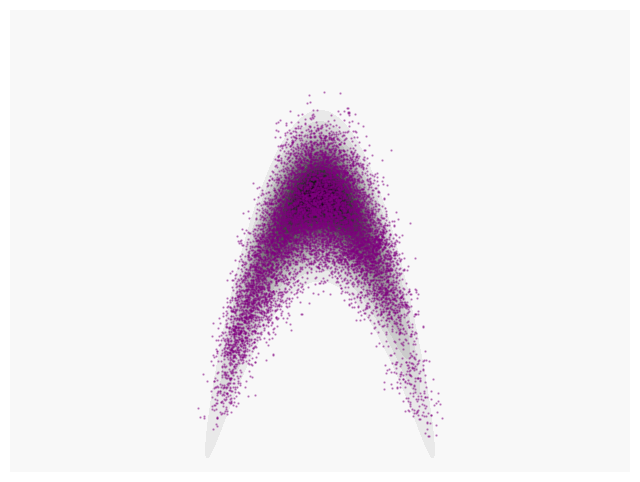

In [86]:
plt.figure(figsize=(8,6))

plt.contourf(x_grid, x_grid, pdf_nD(ux, uy), levels = 16, cmap = "binary")
plt.scatter(lahendHMC2D.T[0], lahendHMC2D.T[1], s = 0.5, color = "purple", alpha= 0.4 )
plt.axis("off")
plt.show()